In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sorting_coordinates(x,y):
    # Sorting the x and y coordinates based on their angle. Will return a vector orderd s.t. x and y start from the coordinates associated to the lowest angle (-180)
    angles = np.arctan2(y, x)

    sort_idx = np.argsort(angles)

    x_sorted = x[sort_idx]
    y_sorted = y[sort_idx]
    
    return x_sorted,y_sorted

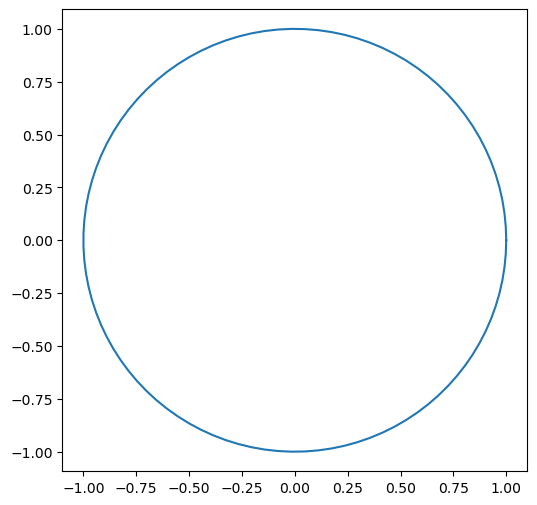

In [3]:
N_points = 100

#  Main Circle in (x,y)
x_main_c = 0
y_main_c = 0

r_main   = 1
theta_main = np.linspace(0, 2*np.pi, N_points)

x_main = x_main_c +  r_main * np.cos(theta_main)
y_main = y_main_c +  r_main * np.sin(theta_main)

x_sorted_main,y_sorted_main= sorting_coordinates(x_main,y_main)

plt.figure(figsize=(6,6))
plt.plot(x_main, y_main)
plt.axis('equal')
plt.show()

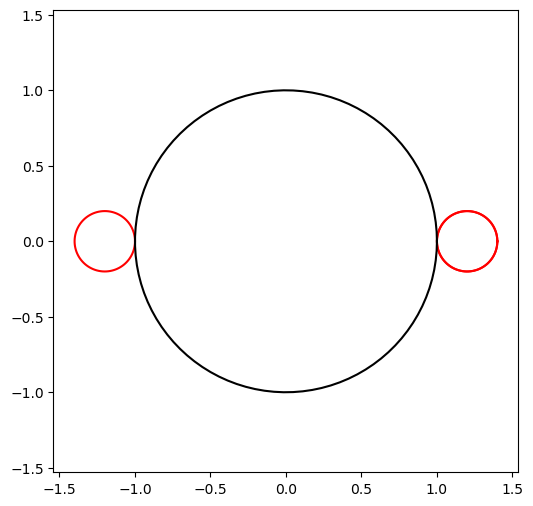

In [17]:
# Evaluate now the externals conferences where the forces will be applied:
# The centers will be distributed symmetrically around the center at a distance equal to radius main + radius externals
N_circles       = 3
N_points_ext    = 100

d_main_ext = 1.2 * r_main
r_ext      = d_main_ext - r_main 

theta_ext  = np.linspace(0, 2*np.pi, N_points_ext)

angle_ext_c = np.linspace(0,2*np.pi,N_circles)
# angle_ext_c = np.linspace(0,2*np.pi,N_circles)

x_ext_c = x_main_c + d_main_ext*np.cos(angle_ext_c)
y_ext_c = y_main_c + d_main_ext*np.sin(angle_ext_c)

x_ext = np.zeros((N_points_ext,N_circles))
y_ext = np.zeros((N_points_ext,N_circles))

for i in range(0,N_circles):
    x_ext[:,i] = x_ext_c[i] + r_ext * np.cos(theta_ext)
    y_ext[:,i] = y_ext_c[i] + r_ext * np.sin(theta_ext)

plt.figure(figsize=(6,6))
plt.plot(x_ext, y_ext , color='red')
plt.plot(x_main,y_main, color='black')
plt.axis('equal')
plt.show()

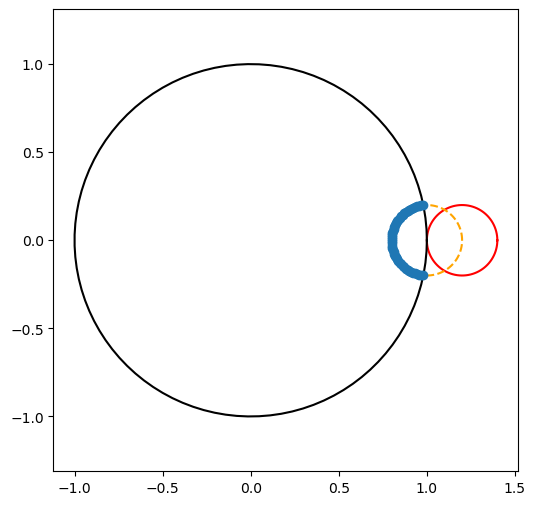

In [11]:
# Simulation of the interaction of a single sphere.
import math

#Advancement s of the conference will be a fraction of the diameter of the external circle 
#For now we will assume that all the circles moves of the same quantity s 
s = 0.5 * (2*r_ext)

N_points_span = 50

o1o3 = r_main + r_ext - s

angle_aperture = np.arccos( (r_ext**2 + o1o3**2 - r_main**2)/ (2 * r_ext * o1o3) )

# theta_span   = np.linspace( angle_ext_c - angle_aperture   , angle_ext_c + angle_aperture , 10)
theta_span   = np.linspace(  angle_ext_c - angle_aperture  + np.pi  , angle_ext_c + angle_aperture + np.pi , N_points_span)

x_new_c = x_ext_c - s*np.cos(angle_ext_c)
y_new_c = y_ext_c - s*np.sin(angle_ext_c)

x_new  = x_new_c +  r_ext*  np.cos(theta_main)
y_new  = y_new_c +  r_ext*  np.sin(theta_main)

x_inner = x_new_c + r_ext*  np.cos(theta_span)
y_inner = y_new_c + r_ext*  np.sin(theta_span)

plt.figure(figsize=(6,6))
plt.plot(x_ext, y_ext , color='red')
plt.plot(x_main,y_main, color='black')
plt.plot(x_new,y_new, linestyle='--',  color='orange')
plt.plot(x_inner,y_inner,'o')
plt.axis('equal')
plt.show()


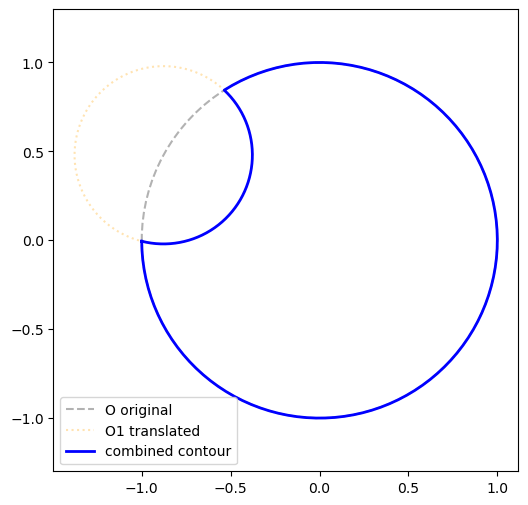

In [ ]:
# Create the new circle

angle_at_O = np.arccos( (r_main**2 + o1o3**2 - r_ext**2) / (2 * r_main * o1o3) )

# Intersection points on O's rim
theta_intersect_1 = angle_ext_c - angle_at_O
theta_intersect_2 = angle_ext_c + angle_at_O

theta_main_outer = np.linspace(theta_intersect_2, theta_intersect_1 + 2*np.pi, N_points_ext)
x_main_outer = r_main * np.cos(theta_main_outer)
y_main_outer = r_main * np.sin(theta_main_outer)

theta_span = np.linspace(angle_ext_c + np.pi + angle_aperture,
                         angle_ext_c + np.pi - angle_aperture, N_points_span)

x_inner = x_new_c + r_ext * np.cos(theta_span)
y_inner = y_new_c + r_ext * np.sin(theta_span)

x_combined = np.concatenate([x_main_outer, x_inner])
y_combined = np.concatenate([y_main_outer, y_inner])

plt.figure(figsize=(6,6))
plt.plot(x_main, y_main, color='black', linestyle='--', alpha=0.3, label='O original')
plt.plot(x_new,  y_new,  color='orange', linestyle='dotted', alpha=0.3, label='O1 translated')
plt.plot(x_combined, y_combined, color='blue', linewidth=2, label='combined contour')
plt.axis('equal')
plt.legend()
plt.show()



In [ ]:
# Save the new coordinates

# Recreate the original circle with same number of points
theta_main = np.linspace(0, 2*np.pi, np.size(x_combined))

x_main = x_main_c +  r_main * np.cos(theta_main)
y_main = y_main_c +  r_main * np.sin(theta_main)


np.save('Coordinates_after.npy', np.array([x_combined, y_combined]))
np.save('Coordinates_before.npy', np.array([x_main, y_main]))


